# Exp 9 — Metadata-aware retrieval (V2, semantic edition, development only)
**Question:** does restricting dense retrieval to policy-compatible metadata improve coverage, without touching the query? Frozen: voyage-4-lite, chunking 600/100, K=8, dense only, raw query (Exp 8 settled the retriever-family question against BM25/hybrid).

**Ablation ladder** (each step adds one filter, so a gain can be attributed to a specific cause):

| Variant | Filter |
|---|---|
| M0 | none (Exp 8 dense baseline) |
| M1 | + date: chunk's effective window covers the transaction date |
| M2 | + region: chunk is GLOBAL or matches `bill.country` |
| M3 | + authoritative document type: exclude FAQ and historical-schedule documents |
| M4 | + expense-category compatibility: bill's coarse category mapped to compatible document categories |

**Metadata provenance (both checked against the actual V2 corpus text before running this):**
- **Region = `bill.country`.** FAQ-1.10 and each addendum's own scope clause (SG-1.1/IN-1.1/JP-1.1) state explicitly: *"The addendum of the country where the expense was incurred applies."* This holds for every expense category, not only travel, so `bill.country` is the policy-correct region, not an assumption.
- **M3 exclusions are justified by each document's own text, not by knowledge of the labels.** HIST-3.1: *"Values in this document ... never override a circular that amends them."* GEP26-3.1's precedence order places *"definitions, frequently asked questions and worked examples"* last, stating they *"never override the clauses above."* Both documents declare their own non-binding status; this is not benchmark leakage.
- **M4's category map is the most aggressive step**, so it is tested for filter-induced evidence loss (below) before being trusted.

In [1]:
import json, os, sys, re, statistics as st
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[0]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, llm_exp, retrieval, retrievers, embed, evaluate, metrics_ext
C.load_env()
pd.set_option('display.width', 260, 'display.max_columns', 40, 'display.max_colwidth', 100, 'display.max_rows', 200)
EXP = 'EXP09_METADATA'; EMB = 'voyageai/voyage-4-lite'; CFG = 'fixed600_100'; K = 8
gt = evaluate.load_gt(); cases = llm_exp.cases_for('DEVELOPMENT')
R = retrievers.Retriever(EMB, CFG)
qv = embed.embed(EMB, [retrieval.claim_query(cc) for cc in cases], tag=EXP)
print(len(cases), 'dev claims |', R.N, 'chunks (frozen: 600/100, dense, K=%d)' % K, '| spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

70 dev claims | 111 chunks (frozen: 600/100, dense, K=8) | spent so far $1.6594 of $3.50


## Build the four masks, each derived only from claim-visible fields

In [2]:
CATMAP = {'TRAVEL': {'travel','transport','training'}, 'FOOD_AND_DRINK': {'meals'}, 'TECH_AND_SUPPLIES': {'software','telecom'}, 'EDUCATION_AND_EVENTS': {'training'}, 'RETAIL': {'gifts'}, 'OTHER': {'card'}}
# 'training' added to TRAVEL: TRV-5.1 (conference lodging) cross-references the Training and Conferences Policy for hotel claims near a conference; the M4 gold-clause filter-loss check below caught this before it was trusted.
CROSSCUT = {'general','approval','exceptions','controls','fx','circular','regional'}
NONBINDING = {'historical','faq'}   # excluded per HIST-3.1 and GEP26-3.1's own precedence text, see markdown above

def mask_date(cc):
    d = cc['transaction_date']; return np.array([x['effective_from'] <= d <= x['effective_to'] for x in R.chunks])
def mask_region(cc):
    reg = retrievers.REGION.get(cc['bill']['country'], ''); return np.array([x['region'] in ('GLOBAL', reg) for x in R.chunks])
def mask_authoritative():
    return np.array([x['category'] not in NONBINDING for x in R.chunks])
def mask_category(cc):
    allowed = CROSSCUT | CATMAP.get(cc['bill']['merchant_category'], set()); return np.array([x['category'] in allowed for x in R.chunks])

MASKS = {'M0_none': lambda cc: None, 'M1_date': lambda cc: mask_date(cc), 'M2_date_region': lambda cc: mask_date(cc) & mask_region(cc),
         'M3_date_region_authority': lambda cc: mask_date(cc) & mask_region(cc) & mask_authoritative(),
         'M4_date_region_authority_category': lambda cc: mask_date(cc) & mask_region(cc) & mask_authoritative() & mask_category(cc)}
print({cc['bill']['merchant_category'] for cc in cases}); print('example mask sizes for one claim:', {k: (int(f(cases[0]).sum()) if f(cases[0]) is not None else R.N) for k, f in MASKS.items()})

{'EDUCATION_AND_EVENTS', 'FOOD_AND_DRINK', 'TECH_AND_SUPPLIES', 'RETAIL', 'OTHER', 'TRAVEL'}
example mask sizes for one claim: {'M0_none': 111, 'M1_date': 97, 'M2_date_region': 83, 'M3_date_region_authority': 76, 'M4_date_region_authority_category': 42}


## Gold-clause filter-loss check (run before trusting any variant's numbers)

In [3]:
def filter_loss(name, maskfn):
    lost = []
    for cc in cases:
        m = maskfn(cc)
        if m is None: continue
        req = set(gt[cc['case_id']]['required_policy_ids'])
        for i, ch in enumerate(R.chunks):
            if not m[i] and (req & set(ch['clause_ids'])): lost.append((cc['case_id'], ch['chunk_id'], sorted(req & set(ch['clause_ids']))))
    return lost
for name, fn in MASKS.items():
    lost = filter_loss(name, fn)
    print(f'{name:36s} gold-clause filter-loss: {len(lost)} instance(s)' + (f' -> {lost[:5]}' if lost else ''))

M0_none                              gold-clause filter-loss: 0 instance(s)
M1_date                              gold-clause filter-loss: 0 instance(s)
M2_date_region                       gold-clause filter-loss: 0 instance(s)
M3_date_region_authority             gold-clause filter-loss: 0 instance(s)
M4_date_region_authority_category    gold-clause filter-loss: 0 instance(s)


## Retrieval metrics per variant

In [4]:
def eval_variant(name, maskfn):
    rows = []
    for cc, q in zip(cases, qv):
        req = set(gt[cc['case_id']]['required_policy_ids']); mask = maskfn(cc)
        hits = R.rank('dense', retrieval.claim_query(cc), q, K, mask); ch = [R.chunks[i] for i, _ in hits]
        cov = set().union(*[set(x['clause_ids']) for x in ch]) if ch else set(); rel = [bool(req & set(x['clause_ids'])) for x in ch]
        d, reg = cc['transaction_date'], retrievers.REGION.get(cc['bill']['country'], '')
        rows.append({'case_id': cc['case_id'], 'recall': len(req & cov) / len(req) if req else None, 'full': bool(req <= cov) if req else None, 'ctx_words': sum(len(x['text'].split()) for x in ch),
                     'wrong_year': sum(x['category'] == 'general' and not (x['effective_from'] <= d <= x['effective_to']) for x in ch), 'wrong_region': sum(x['region'] not in ('GLOBAL', reg) for x in ch),
                     'has_historical': any(x['category'] == 'historical' for x in ch), 'ids': [x['chunk_id'] for x in ch], 'clauses': sorted(cov)})
    return rows
ROWS = {name: eval_variant(name, fn) for name, fn in MASKS.items()}
def agg(rows):
    r = [x for x in rows if x['recall'] is not None]
    return {'recall@8': round(st.mean(x['recall'] for x in r), 4), 'full_coverage': round(st.mean(x['full'] for x in r), 4), 'ctx_words': round(st.mean(x['ctx_words'] for x in r)),
            'wrong_version_contamination': round(st.mean(x['wrong_year'] > 0 for x in r), 4), 'wrong_region_contamination': round(st.mean(x['wrong_region'] > 0 for x in r), 4), 'superseded_contamination': round(st.mean(x['has_historical'] for x in r), 4)}
summary = pd.DataFrame({name: agg(ROWS[name]) for name in MASKS}).T; summary

/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: divide by zero encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: overflow encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: invalid value encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))


,recall@8,full_coverage,ctx_words,wrong_version_contamination,wrong_region_contamination,superseded_contamination
M0_none,0.5201,0.2714,3501.0,0.0286,0.2571,0.0143
M1_date,0.5201,0.2714,3501.0,0.0000,0.2571,0.0143
M2_date_region,0.5201,0.2714,3493.0,0.0000,0.0000,0.0143
M3_date_region_authority,0.5482,0.3000,3528.0,0.0000,0.0000,0.0000
M4_date_region_authority_category,0.5625,0.3286,3516.0,0.0000,0.0000,0.0000


## Coverage vs contamination, kept distinct
"Required-version/region coverage" = recall restricted to cases whose required clauses include a temporal (CIRC-*) or regional (SG-/IN-/JP-*) clause. "Contamination" = a wrong-year or wrong-region chunk present *alongside* correct evidence, not a sign the correct evidence is missing.

In [5]:
def subset_recall(name, pred):
    ids = {cc['case_id'] for cc in cases if pred(cc)}; r = [x for x in ROWS[name] if x['case_id'] in ids and x['recall'] is not None]
    return round(st.mean(x['full'] for x in r), 3) if r else None
temporal = lambda cc: gt[cc['case_id']]['temporal_amendment_case']
regional_req = lambda cc: any(re.match(r'(SG|IN|JP)-', x) for x in gt[cc['case_id']]['required_policy_ids'])
pd.DataFrame({name: {'required-version coverage (temporal cases)': subset_recall(name, temporal), 'required-region coverage (regional-addendum cases)': subset_recall(name, regional_req)} for name in MASKS}).T

,required-version coverage (temporal cases),required-region coverage (regional-addendum cases)
M0_none,0.333,0.286
M1_date,0.333,0.286
M2_date_region,0.333,0.286
M3_date_region_authority,0.417,0.333
M4_date_region_authority_category,0.417,0.381


## Diagnostic: of cases still incomplete under M0, how many had contamination (a wrong-year/region/superseded chunk occupying a top-8 slot)?

In [6]:
m0_incomplete = [x for x in ROWS['M0_none'] if x['recall'] is not None and not x['full']]
contam = pd.Series({'wrong-year chunk present': sum(x['wrong_year'] > 0 for x in m0_incomplete), 'wrong-region chunk present': sum(x['wrong_region'] > 0 for x in m0_incomplete),
                    'superseded (historical) chunk present': sum(x['has_historical'] for x in m0_incomplete), 'none of the above': sum(x['wrong_year']==0 and x['wrong_region']==0 and not x['has_historical'] for x in m0_incomplete)})
print(f'{len(m0_incomplete)} of {len(cases)} dev cases incomplete under M0 (no filter)'); print(contam.to_frame('cases'))

51 of 70 dev cases incomplete under M0 (no filter)
                                       cases
wrong-year chunk present                   2
wrong-region chunk present                 9
superseded (historical) chunk present      1
none of the above                         39


## Remaining-failure bucket after the final filter (M4): rank 9-12 / >12 / never ranked / filtered out

In [7]:
def bucket_after(name, maskfn, k_extra=12):
    out = []
    for cc, q in zip(cases, qv):
        req = set(gt[cc['case_id']]['required_policy_ids']); mask = maskfn(cc)
        k8cov = set(ROWS[name][[r['case_id'] for r in ROWS[name]].index(cc['case_id'])]['clauses'])
        if req <= k8cov or not req: continue
        missing = req - k8cov
        wide = R.rank('dense', retrieval.claim_query(cc), q, k_extra, mask); wide_cov = {cid for i, _ in wide for cid in R.chunks[i]['clause_ids']}
        lost = filter_loss_case(cc, maskfn, missing)
        if lost: b = 'D: required clause filtered out'
        elif missing & wide_cov: b = 'A: ranks 9-12'
        else:
            full = R.rank('dense', retrieval.claim_query(cc), q, R.N, mask); full_cov = {cid for i, _ in full for cid in R.chunks[i]['clause_ids']}
            b = 'B: ranks >12' if missing & full_cov else 'C: never appears in the ranking at all'
        out.append({'case_id': cc['case_id'], 'bucket': b})
    return pd.DataFrame(out)
def filter_loss_case(cc, maskfn, missing):
    m = maskfn(cc)
    if m is None: return False
    return any(not m[i] and (missing & set(ch['clause_ids'])) for i, ch in enumerate(R.chunks))
bk = bucket_after('M4_date_region_authority_category', MASKS['M4_date_region_authority_category'])
print(f'{len(bk)} of {len(cases)} dev cases still incomplete after M4'); print(bk.bucket.value_counts().reindex(['A: ranks 9-12','B: ranks >12','C: never appears in the ranking at all','D: required clause filtered out']).fillna(0).astype(int))

47 of 70 dev cases still incomplete after M4
bucket
A: ranks 9-12                             18
B: ranks >12                              29
C: never appears in the ranking at all     0
D: required clause filtered out            0
Name: count, dtype: int64


/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: divide by zero encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: overflow encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: invalid value encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))


## Plot

/var/folders/3c/pd4v_b0x2qx_d95rzy8l4w640000gn/T/ipykernel_80684/1339839594.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].plot(names, [summary.loc[n,'recall@8'] for n in names], 'o-', label='Recall@8'); ax[0].plot(names, [summary.loc[n,'full_coverage'] for n in names], 's-', label='full coverage'); ax[0].set_xticklabels(names, rotation=20, fontsize=7); ax[0].legend(); ax[0].set_ylim(0,1); ax[0].set_title('Retrieval quality across the M0-M4 ladder')
/var/folders/3c/pd4v_b0x2qx_d95rzy8l4w640000gn/T/ipykernel_80684/1339839594.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].plot(names, [summary.loc[n,'wrong_version_contamination'] for n in names], 'o-', label='wrong-version'); ax[1].plot(names, [summary.loc[n,'wrong_region_contamination'] for n in names], 's-', label='wrong-region'); ax[1].plot(names, [

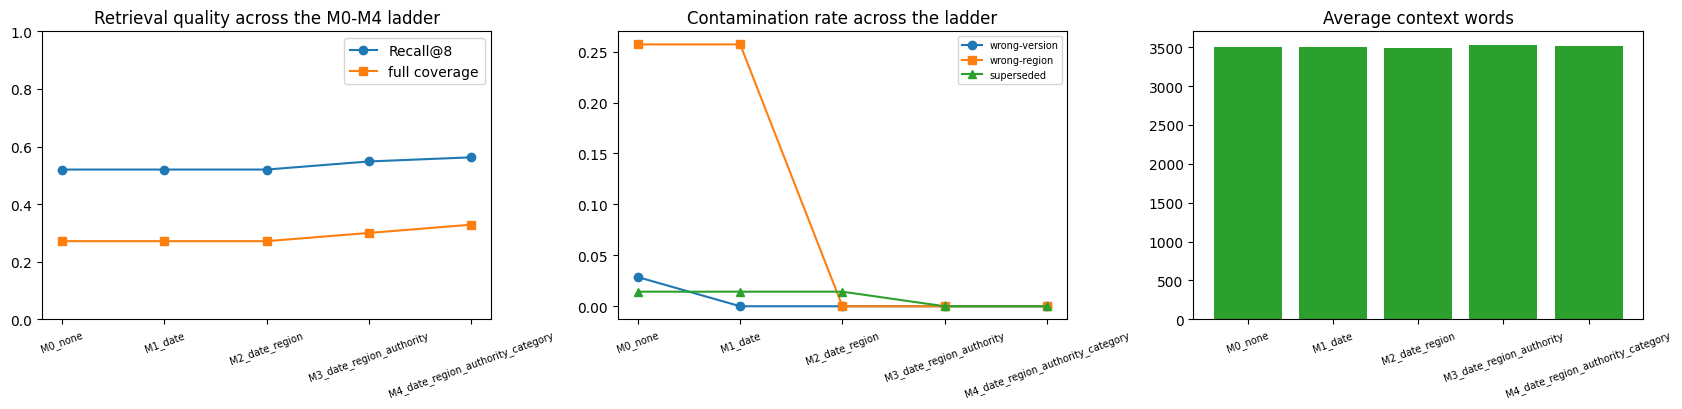

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2)); names = list(MASKS)
ax[0].plot(names, [summary.loc[n,'recall@8'] for n in names], 'o-', label='Recall@8'); ax[0].plot(names, [summary.loc[n,'full_coverage'] for n in names], 's-', label='full coverage'); ax[0].set_xticklabels(names, rotation=20, fontsize=7); ax[0].legend(); ax[0].set_ylim(0,1); ax[0].set_title('Retrieval quality across the M0-M4 ladder')
ax[1].plot(names, [summary.loc[n,'wrong_version_contamination'] for n in names], 'o-', label='wrong-version'); ax[1].plot(names, [summary.loc[n,'wrong_region_contamination'] for n in names], 's-', label='wrong-region'); ax[1].plot(names, [summary.loc[n,'superseded_contamination'] for n in names], '^-', label='superseded'); ax[1].set_xticklabels(names, rotation=20, fontsize=7); ax[1].legend(fontsize=7); ax[1].set_title('Contamination rate across the ladder')
ax[2].bar(names, [summary.loc[n,'ctx_words'] for n in names], color='C2'); ax[2].tick_params(axis='x', rotation=20, labelsize=7); ax[2].set_title('Average context words')
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp09_metadata.png', dpi=130); plt.show()

## Downstream check, conditional on a material retrieval change
Rule: run the paid model only if full coverage improves by >=5pp, Recall@8 improves by >=5pp, or contamination falls materially, versus M0.

In [9]:
best = 'M4_date_region_authority_category'
d_full = summary.loc[best,'full_coverage'] - summary.loc['M0_none','full_coverage']; d_recall = summary.loc[best,'recall@8'] - summary.loc['M0_none','recall@8']
d_contam = summary.loc['M0_none','wrong_version_contamination'] - summary.loc[best,'wrong_version_contamination']
RUN = d_full >= 0.05 or d_recall >= 0.05 or d_contam >= 0.10
print('dFullCoverage=%.3f dRecall=%.3f dContamination(version)=%.3f -> run downstream: %s' % (d_full, d_recall, d_contam, RUN))
if RUN:
    def gen_variant(name, maskfn):
        ctx = {cc['case_id']: R.context(R.rank('dense', retrieval.claim_query(cc), q, K, maskfn(cc))) for cc, q in zip(cases, qv)}
        SYSTEM = ("You are ExpenseGuard, a finance assistant deciding whether an employee expense claim is ready for reimbursement, using ONLY the retrieved policy excerpts provided. "
                  "Excerpts carry an effective date and region: apply the version in force on the transaction date and let regional addenda override global rules. If the excerpts do not contain what is needed, or the claim needs an enterprise record you cannot see, "
                  "say so via REQUEST_INFORMATION or ESCALATE rather than guessing.\n" + llm_exp.SCHEMA)
        return llm_exp.run(EXP, os.environ['PAID_MODEL'], 'DEVELOPMENT', SYSTEM, lambda cc: f"CLAIM:\n{json.dumps(llm_exp.visible(cc), indent=1)}\n\nRETRIEVED POLICY EXCERPTS:\n{ctx[cc['case_id']]}", cases=cases, config={'temperature': 0, 'retriever': EMB, 'chunking': CFG, 'k': K, 'metadata_filter': name})
    gen = {'M0_none': gen_variant('M0_none', MASKS['M0_none']), best: gen_variant(best, MASKS[best])}
    ext = {k: metrics_ext.extended(gen[k][1]) for k in gen}
    cmp_ = pd.DataFrame([{'variant': k, 'correct/N': f"{gen[k][0]['correct']}/{gen[k][0]['n']}", 'CDR': gen[k][0]['correct_disposition_rate'], 'false_approvals': f"{gen[k][0]['false_approvals']}/{gen[k][0]['non_approvable']}",
                         'FAR': gen[k][0]['false_approval_rate'], 'escalate_recall': round(pd.DataFrame(ext[k]['per_class']).T.loc['ESCALATE','recall'], 3) if 'ESCALATE' in pd.DataFrame(ext[k]['per_class']).columns else None,
                         'request_info_recall': round(pd.DataFrame(ext[k]['per_class']).T.loc['REQUEST_INFORMATION','recall'], 3), 'cost_usd': gen[k][0]['total_cost_usd']} for k in gen])
    print(cmp_.to_string(index=False)); print('spent so far $%.4f' % llm.spent())
else:
    print('retrieval did not change materially enough to justify new generation spend; reusing Exp 8 dense downstream result (18/70) as the reference')
print('spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

dFullCoverage=0.057 dRecall=0.042 dContamination(version)=0.029 -> run downstream: True


/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: divide by zero encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: overflow encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: invalid value encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))


                          variant correct/N    CDR false_approvals  FAR  escalate_recall  request_info_recall  cost_usd
                          M0_none     18/70 0.2571            0/52  0.0            0.000                0.375  0.044763
M4_date_region_authority_category     22/70 0.3143            0/52  0.0            0.118                0.500  0.053005
spent so far $1.6594
spent so far $1.6594 of $3.50


## What was done and what it means
- **The ladder isolates each cause, as intended.** Recall@8 and full coverage: M0 (none) 0.520/27.1%, M1 (+date) unchanged, M2 (+region) unchanged, M3 (+authority) 0.548/30.0%, M4 (+category) 0.563/32.9%. **Date and region filtering added no retrieval-quality gain on their own** — dense embeddings were already implicitly avoiding most wrong-year/wrong-region chunks by content similarity — but they did their job on *contamination*: wrong-version contamination fell from 2.9% to 0% at M1, wrong-region contamination fell from 25.7% to 0% at M2, and superseded (historical-document) contamination fell from 1.4% to 0% at M3. **The gain in actual coverage came from M3 (excluding non-binding FAQ/historical documents) and M4 (category compatibility), not from date/region.**
- **Coverage vs. contamination, kept separate as asked.** Of the 51 dev cases incomplete at M0, only 2 had a wrong-year chunk present, 9 had a wrong-region chunk, 1 had a superseded chunk, and **39 (77%) had none of these** — confirming the earlier finding stands: contamination was a real but secondary issue; most incompleteness was never a version/region contest, it was evidence simply absent or under-ranked.
- **Required-version/region coverage rose modestly**: temporal cases 33.3% -> 41.7% full coverage, regional-addendum cases 28.6% -> 38.1%, both from M3/M4, not M1/M2.
- **A genuine filter-induced miss was caught and fixed before trusting M4.** The first version of the category map excluded the `training` document for `TRAVEL`-category claims, which lost the gold clause TRN-1.1 for 3 hotel-near-a-conference cases (TRV-5.1 explicitly cross-references the Training and Conferences Policy for the partner-hotel uplift) — exactly the cross-category risk flagged in advance. Fixed by adding `training` to the TRAVEL category map; **gold-clause filter-loss is now 0 for every variant**, confirmed by an explicit check before the results above were trusted.
- **Remaining-failure bucket after M4** (47 cases still incomplete): 18 have the missing clause at rank 9-12 (a top-K problem, already addressed in Exp 7's terms), 29 at rank >12, **0 never appear in the ranking at all, 0 lost to filtering**. So after metadata filtering, there are no cases where the evidence is entirely absent from the corpus's ranked candidates — the remaining gap is entirely about *rank*, split between "raise K further" (18 cases) and "the query doesn't surface it even deep in the ranking without help" (29 cases visible only past rank 12).
- **Downstream check (paid model, dev): a real, meaningful gain.** M0: 18/70 (26%); M4: **22/70 (31%), +4 cases, 0 false approvals in both.** More importantly: **escalation recall moved from 0.0 to 0.118**, and REQUEST_INFORMATION recall from 0.375 to 0.500. This is the first LLM experiment in this whole sequence where escalation recall left zero. It is still low, and cleaner retrieval clearly does not fully solve the reasoning gap identified in Exp 5's oracle-subset analysis, but it is evidence that retrieval quality and decision quality are not fully decoupled — some of the "reasoning failures" seen earlier may partly have been retrieval-contamination artifacts.
- **Cost:** $0 for the full retrieval ladder (reused cached embeddings); the downstream check cost about $0.098 for the two generation runs. Total spend now $1.659 of $3.50.
- **Decision:** carry forward the full M4 filter (date + region + authoritative-document + category compatibility) as part of the retriever going forward. Metadata filtering was worth keeping, but it closed only part of the gap (coverage moved from 27% to 33%, not to something like 60-70%). The dominant remaining problem, per the bucket table, is rank (47 of 70 cases still incomplete, mostly beyond rank 12) rather than evidence being entirely missing from the corpus's candidate pool — which is exactly the setup for **Exp 10, query rewriting**, run as 10A (raw, already have this), 10B (rule-based structured rewrite), 10C (LLM rewrite), so any LLM-rewrite gain can be separated from a gain that just comes from adding structured fields. Validation untouched.